# Telco Customer Churn

**Autor:** Javier Herrero Pérez 

**Fecha:** Enero 2026  

**Contexto:** Análisis de datos de telecomunicaciones para la identificación proactiva de clientes en riesgo de abandono.


# 1. Introducción y Contexto del Proyecto

## Descripción
Este proyecto aborda uno de los desafíos más críticos en el sector de las telecomunicaciones: la **fuga de clientes** (o *Churn*). La retención de clientes es, en promedio, cinco veces más económica que la adquisición de nuevos, por lo que identificar proactivamente a los usuarios con intención de abandonar el servicio permite a la compañía ejecutar estrategias de fidelización quirúrgicas y eficientes.

El conjunto de datos utilizado es el célebre **Telco Customer Churn**, disponible en [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn), que contiene información sobre una compañía de telecomunicaciones ficticia que proporcionó servicios de telefonía e internet a 7043 clientes en California.

## Objetivos
1.  **Analítico:** Comprender las causas raíz del abandono mediante un estudio de variables demográficas, servicios contratados y comportamiento de facturación.
2.  **Predictivo:** Construir un modelo de clasificación robusto que maximice el **F1-Score**, equilibrando la capacidad de detección (*Recall*) con la precisión de las alertas.
3.  **Estratégico:** Proporcionar una herramienta de toma de decisiones basada en un **Ensemble de Modelos** y un ajuste dinámico de umbrales (*Threshold Tuning*).

## Innovaciones Técnicas del Proyecto
A diferencia de aproximaciones estándar, este notebook implementa:
* **Análisis de Residuos:** Uso de una regresión lineal OLS para detectar anomalías de facturación, integrando los residuos como una nueva *feature* predictiva.
* **Validación Rigurosa:** Aplicación de **SMOTE** solo en el set de entrenamiento mediante *cross-validation* para evitar el sesgo de *data leakage*.
* **Inteligencia Colectiva:** Uso de un **Voting Classifier** que combina la potencia de XGBoost, Random Forest y LightGBM.
* **Optimización de Umbral:** Búsqueda del umbral óptimo mediante `TunedThresholdClassifierCV` para alinear el modelo con los costes operativos de negocio.



## CodeBook

### Información del cliente

<table data-path-to-node="5"><thead><tr><td><span data-path-to-node="5,0,0,0">Variable</span></td><td><span data-path-to-node="5,0,1,0">Tipo</span></td><td><span data-path-to-node="5,0,2,0">Descripción</span></td><td><span data-path-to-node="5,0,3,0">Valores posibles</span></td></tr></thead><tbody><tr><td><span data-path-to-node="5,1,0,0"><b data-path-to-node="5,1,0,0" data-index-in-node="0">customerID</b></span></td><td><span data-path-to-node="5,1,1,0">String</span></td><td><span data-path-to-node="5,1,2,0">Identificador único del cliente.</span></td><td><span data-path-to-node="5,1,3,0">Ej: <code data-path-to-node="5,1,3,0" data-index-in-node="4">7590-VHVEG</code></span></td></tr><tr><td><span data-path-to-node="5,2,0,0"><b data-path-to-node="5,2,0,0" data-index-in-node="0">gender</b></span></td><td><span data-path-to-node="5,2,1,0">Categórica</span></td><td><span data-path-to-node="5,2,2,0">Género del cliente.</span></td><td><span data-path-to-node="5,2,3,0"><code data-path-to-node="5,2,3,0" data-index-in-node="0">Female</code>, <code data-path-to-node="5,2,3,0" data-index-in-node="8">Male</code></span></td></tr><tr><td><span data-path-to-node="5,3,0,0"><b data-path-to-node="5,3,0,0" data-index-in-node="0">SeniorCitizen</b></span></td><td><span data-path-to-node="5,3,1,0">Binaria</span></td><td><span data-path-to-node="5,3,2,0">Indica si el cliente es una persona mayor.</span></td><td><span data-path-to-node="5,3,3,0"><code data-path-to-node="5,3,3,0" data-index-in-node="0">0</code> (No), <code data-path-to-node="5,3,3,0" data-index-in-node="8">1</code> (Sí)</span></td></tr><tr><td><span data-path-to-node="5,4,0,0"><b data-path-to-node="5,4,0,0" data-index-in-node="0">Partner</b></span></td><td><span data-path-to-node="5,4,1,0">Binaria</span></td><td><span data-path-to-node="5,4,2,0">Indica si el cliente tiene pareja.</span></td><td><span data-path-to-node="5,4,3,0"><code data-path-to-node="5,4,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="5,4,3,0" data-index-in-node="5">No</code></span></td></tr><tr><td><span data-path-to-node="5,5,0,0"><b data-path-to-node="5,5,0,0" data-index-in-node="0">Dependents</b></span></td><td><span data-path-to-node="5,5,1,0">Binaria</span></td><td><span data-path-to-node="5,5,2,0">Indica si el cliente tiene personas a su cargo.</span></td><td><span data-path-to-node="5,5,3,0"><code data-path-to-node="5,5,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="5,5,3,0" data-index-in-node="5">No</code></span></td></tr></tbody></table>

### Información de la cuenta y contrato

<table data-path-to-node="9"><thead><tr><td><span data-path-to-node="9,0,0,0">Variable</span></td><td><span data-path-to-node="9,0,1,0">Tipo</span></td><td><span data-path-to-node="9,0,2,0">Descripción</span></td><td><span data-path-to-node="9,0,3,0">Valores posibles</span></td></tr></thead><tbody><tr><td><span data-path-to-node="9,1,0,0"><b data-path-to-node="9,1,0,0" data-index-in-node="0">tenure</b></span></td><td><span data-path-to-node="9,1,1,0">Numérica</span></td><td><span data-path-to-node="9,1,2,0">Meses que el cliente ha permanecido en la compañía.</span></td><td><span data-path-to-node="9,1,3,0">0 - 72</span></td></tr><tr><td><span data-path-to-node="9,2,0,0"><b data-path-to-node="9,2,0,0" data-index-in-node="0">Contract</b></span></td><td><span data-path-to-node="9,2,1,0">Categórica</span></td><td><span data-path-to-node="9,2,2,0">Tipo de contrato actual del cliente.</span></td><td><span data-path-to-node="9,2,3,0"><code data-path-to-node="9,2,3,0" data-index-in-node="0">Month-to-month</code>, <code data-path-to-node="9,2,3,0" data-index-in-node="16">One year</code>, <code data-path-to-node="9,2,3,0" data-index-in-node="26">Two year</code></span></td></tr><tr><td><span data-path-to-node="9,3,0,0"><b data-path-to-node="9,3,0,0" data-index-in-node="0">PaperlessBilling</b></span></td><td><span data-path-to-node="9,3,1,0">Binaria</span></td><td><span data-path-to-node="9,3,2,0">Si el cliente tiene factura electrónica.</span></td><td><span data-path-to-node="9,3,3,0"><code data-path-to-node="9,3,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="9,3,3,0" data-index-in-node="5">No</code></span></td></tr><tr><td><span data-path-to-node="9,4,0,0"><b data-path-to-node="9,4,0,0" data-index-in-node="0">PaymentMethod</b></span></td><td><span data-path-to-node="9,4,1,0">Categórica</span></td><td><span data-path-to-node="9,4,2,0">Método de pago del cliente.</span></td><td><span data-path-to-node="9,4,3,0"><code data-path-to-node="9,4,3,0" data-index-in-node="0">Electronic check</code>, <code data-path-to-node="9,4,3,0" data-index-in-node="18">Mailed check</code>, <code data-path-to-node="9,4,3,0" data-index-in-node="32">Bank transfer</code>, <code data-path-to-node="9,4,3,0" data-index-in-node="47">Credit card</code></span></td></tr><tr><td><span data-path-to-node="9,5,0,0"><b data-path-to-node="9,5,0,0" data-index-in-node="0">MonthlyCharges</b></span></td><td><span data-path-to-node="9,5,1,0">Numérica</span></td><td><span data-path-to-node="9,5,2,0">El importe cobrado al cliente mensualmente.</span></td><td><span data-path-to-node="9,5,3,0">18.25 - 118.75</span></td></tr><tr><td><span data-path-to-node="9,6,0,0"><b data-path-to-node="9,6,0,0" data-index-in-node="0">TotalCharges</b></span></td><td><span data-path-to-node="9,6,1,0">Numérica</span></td><td><span data-path-to-node="9,6,2,0">El importe total cobrado al cliente.</span></td><td><span data-path-to-node="9,6,3,0"><b data-path-to-node="9,6,3,0" data-index-in-node="0">¡Ojo! Contiene vacíos</b></span></td></tr></tbody></table>

### Servicios contratados

<table data-path-to-node="13"><thead><tr><td><span data-path-to-node="13,0,0,0">Variable</span></td><td><span data-path-to-node="13,0,1,0">Tipo</span></td><td><span data-path-to-node="13,0,2,0">Descripción</span></td><td><span data-path-to-node="13,0,3,0">Valores posibles</span></td></tr></thead><tbody><tr><td><span data-path-to-node="13,1,0,0"><b data-path-to-node="13,1,0,0" data-index-in-node="0">PhoneService</b></span></td><td><span data-path-to-node="13,1,1,0">Binaria</span></td><td><span data-path-to-node="13,1,2,0">Si tiene servicio telefónico.</span></td><td><span data-path-to-node="13,1,3,0"><code data-path-to-node="13,1,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,1,3,0" data-index-in-node="5">No</code></span></td></tr><tr><td><span data-path-to-node="13,2,0,0"><b data-path-to-node="13,2,0,0" data-index-in-node="0">MultipleLines</b></span></td><td><span data-path-to-node="13,2,1,0">Categórica</span></td><td><span data-path-to-node="13,2,2,0">Si tiene varias líneas telefónicas.</span></td><td><span data-path-to-node="13,2,3,0"><code data-path-to-node="13,2,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,2,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,2,3,0" data-index-in-node="9">No phone service</code></span></td></tr><tr><td><span data-path-to-node="13,3,0,0"><b data-path-to-node="13,3,0,0" data-index-in-node="0">InternetService</b></span></td><td><span data-path-to-node="13,3,1,0">Categórica</span></td><td><span data-path-to-node="13,3,2,0">Tipo de proveedor de internet.</span></td><td><span data-path-to-node="13,3,3,0"><code data-path-to-node="13,3,3,0" data-index-in-node="0">DSL</code>, <code data-path-to-node="13,3,3,0" data-index-in-node="5">Fiber optic</code>, <code data-path-to-node="13,3,3,0" data-index-in-node="18">No</code></span></td></tr><tr><td><span data-path-to-node="13,4,0,0"><b data-path-to-node="13,4,0,0" data-index-in-node="0">OnlineSecurity</b></span></td><td><span data-path-to-node="13,4,1,0">Categórica</span></td><td><span data-path-to-node="13,4,2,0">Si tiene servicio de seguridad online.</span></td><td><span data-path-to-node="13,4,3,0"><code data-path-to-node="13,4,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,4,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,4,3,0" data-index-in-node="9">No internet service</code></span></td></tr><tr><td><span data-path-to-node="13,5,0,0"><b data-path-to-node="13,5,0,0" data-index-in-node="0">OnlineBackup</b></span></td><td><span data-path-to-node="13,5,1,0">Categórica</span></td><td><span data-path-to-node="13,5,2,0">Si tiene servicio de copia de seguridad.</span></td><td><span data-path-to-node="13,5,3,0"><code data-path-to-node="13,5,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,5,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,5,3,0" data-index-in-node="9">No internet service</code></span></td></tr><tr><td><span data-path-to-node="13,6,0,0"><b data-path-to-node="13,6,0,0" data-index-in-node="0">DeviceProtection</b></span></td><td><span data-path-to-node="13,6,1,0">Categórica</span></td><td><span data-path-to-node="13,6,2,0">Si tiene seguro de dispositivo.</span></td><td><span data-path-to-node="13,6,3,0"><code data-path-to-node="13,6,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,6,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,6,3,0" data-index-in-node="9">No internet service</code></span></td></tr><tr><td><span data-path-to-node="13,7,0,0"><b data-path-to-node="13,7,0,0" data-index-in-node="0">TechSupport</b></span></td><td><span data-path-to-node="13,7,1,0">Categórica</span></td><td><span data-path-to-node="13,7,2,0">Si tiene servicio de soporte técnico.</span></td><td><span data-path-to-node="13,7,3,0"><code data-path-to-node="13,7,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,7,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,7,3,0" data-index-in-node="9">No internet service</code></span></td></tr><tr><td><span data-path-to-node="13,8,0,0"><b data-path-to-node="13,8,0,0" data-index-in-node="0">StreamingTV</b></span></td><td><span data-path-to-node="13,8,1,0">Categórica</span></td><td><span data-path-to-node="13,8,2,0">Si tiene TV por streaming.</span></td><td><span data-path-to-node="13,8,3,0"><code data-path-to-node="13,8,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,8,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,8,3,0" data-index-in-node="9">No internet service</code></span></td></tr><tr><td><span data-path-to-node="13,9,0,0"><b data-path-to-node="13,9,0,0" data-index-in-node="0">StreamingMovies</b></span></td><td><span data-path-to-node="13,9,1,0">Categórica</span></td><td><span data-path-to-node="13,9,2,0">Si tiene películas por streaming.</span></td><td><span data-path-to-node="13,9,3,0"><code data-path-to-node="13,9,3,0" data-index-in-node="0">Yes</code>, <code data-path-to-node="13,9,3,0" data-index-in-node="5">No</code>, <code data-path-to-node="13,9,3,0" data-index-in-node="9">No internet service</code></span></td></tr></tbody></table>

### Variable objetivo

<table data-path-to-node="17"><thead><tr><td><span data-path-to-node="17,0,0,0">Variable</span></td><td><span data-path-to-node="17,0,1,0">Tipo</span></td><td><span data-path-to-node="17,0,2,0">Descripción</span></td><td><span data-path-to-node="17,0,3,0">Valores posibles</span></td></tr></thead><tbody><tr><td><span data-path-to-node="17,1,0,0"><b data-path-to-node="17,1,0,0" data-index-in-node="0">Churn</b></span></td><td><span data-path-to-node="17,1,1,0">Binaria</span></td><td><span data-path-to-node="17,1,2,0">Indica si el cliente canceló el servicio en el último mes.</span></td><td><span data-path-to-node="17,1,3,0"><code data-path-to-node="17,1,3,0" data-index-in-node="0">Yes</code> (Se fue), <code data-path-to-node="17,1,3,0" data-index-in-node="14">No</code> (Sigue)</span></td></tr></tbody></table>

# 2. Cargar librerías y datos



In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import statsmodels.api as sm

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

import statsmodels.stats.api as sms
import scipy.stats as stats


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# 3. Análisis Exploratorio de Datos


In [88]:
df=pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [89]:
r,c=df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Limpieza de datos

 La variable ``TotalCharges`` contiene registros con cadenas vacías. Se realizará un filtrado de estos casos para verificar si corresponden a clientes con tenure = 0 (usuarios que aún no han completado su primer ciclo de facturación), con el fin de decidir la estrategia de limpieza de datos más robusta.

In [90]:
dfNaN=df[df["TotalCharges"]==" "]
dfNaN.head()
rNaN,cNaN=dfNaN.shape
print(f"Porcentaje de filas vacías {(rNaN/r)*100:.2f}%")

Porcentaje de filas vacías 0.16%


Dado que solo el 0.16% de las instancias tienen valores perdidos de TotalCharges se ha decidido eliminarlas

In [91]:
def limpieza(df):


    colnames=df.columns.values
    df.columns=[col.lower() for col in colnames] # Para que todas las variables esten en minúscula

    df["totalcharges"]=pd.to_numeric(df["totalcharges"],errors="coerce") # Eliminar valores Na
    df.dropna(inplace=True)

    df=df.drop(columns=["customerid"]) # Eliminar columna de id

    cols_category=df.select_dtypes(include=['str']).columns.tolist()
    cols_category.append("seniorcitizen")
    for col in cols_category:
        df[col]=df[col].astype("category") # Transformar a tipo categórico

    df["totalcharges_monthlycharges_log"]=np.log(df["totalcharges"]/df["monthlycharges"])
    df["tenure_log"]=np.log(df["tenure"])

    return(df)
df=pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df=limpieza(df)

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   gender                           7032 non-null   category
 1   seniorcitizen                    7032 non-null   category
 2   partner                          7032 non-null   category
 3   dependents                       7032 non-null   category
 4   tenure                           7032 non-null   int64   
 5   phoneservice                     7032 non-null   category
 6   multiplelines                    7032 non-null   category
 7   internetservice                  7032 non-null   category
 8   onlinesecurity                   7032 non-null   category
 9   onlinebackup                     7032 non-null   category
 10  deviceprotection                 7032 non-null   category
 11  techsupport                      7032 non-null   category
 12  streamingtv           

### OneHotEncoding

La mayoría de los algoritmos de Machine Learning, incluyendo **XGBoost** y **Random Forest**, requieren que las entradas sean numéricas para poder realizar cálculos matemáticos (como el cálculo de gradientes o la partición de nodos). 

Se ha seleccionado la técnica de **One-Hot Encoding** por las siguientes razones:

* **Evita la Jerarquía Ficticia:** A diferencia del *Label Encoding*, el One-Hot Encoding no asigna un orden numérico (1, 2, 3...) a categorías que no lo tienen (ej. "DSL", "Fiber Optic"). Esto evita que el modelo interprete erróneamente que una categoría es "mayor" que otra.
* **Compatibilidad con Modelos Lineales:** Dado que nuestro Ensemble incluye componentes que se benefician de la linealidad, esta técnica permite que el modelo asigne pesos independientes a cada categoría.
* **Manejo de la Cardinalidad:** Al ser variables con pocas categorías (baja cardinalidad), el incremento en la dimensionalidad del dataset es mínimo y manejable, facilitando la interpretación de la importancia de cada servicio específico en la fuga de clientes.

Forma del dataframe original: (7032, 22)
Forma del dataframe tras One-Hot: (7032, 49)


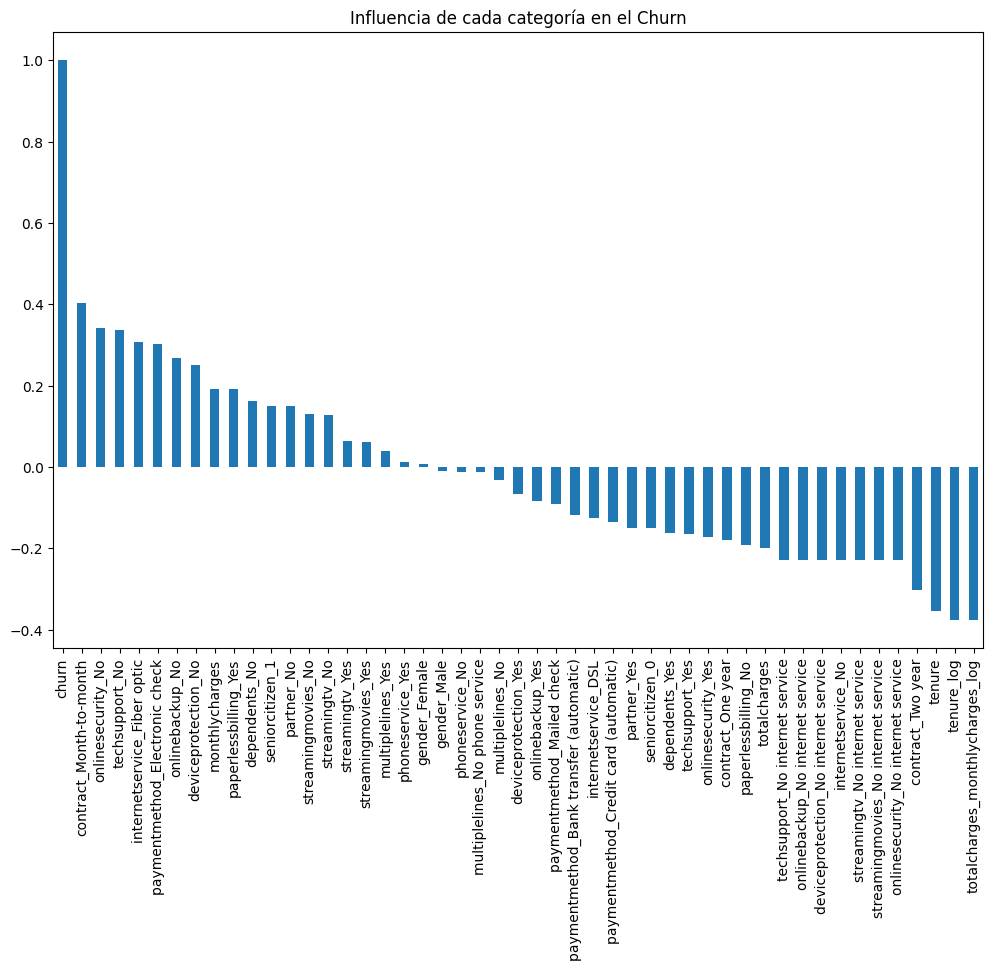

In [ ]:
df_ml = df.copy()

df_ml['churn'] = df_ml['churn'].astype("str").map({'Yes': 1, 'No': 0})
df_ml = pd.get_dummies(df_ml, drop_first=True,dtype=int)

print(f"Forma del dataframe original: {df.shape}")
print(f"Forma del dataframe tras One-Hot: {df_ml.shape}")

plt.figure(figsize=(12, 8))
df_ml.corr()['churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('Influencia de cada categoría en el Churn')
plt.show()

### Relación entre ``totalcharges_monthlycharges_log`` y ```tenure_log```

En esta sección exploramos la estructura matemática que rige la facturación de la compañía. Partimos de la premisa lógica de que los cargos totales son, en gran medida, el producto de la cuota mensual por el tiempo de permanencia:
$$TotalCharges \approx MonthlyCharges \times Tenure$$

Al aplicar transformaciones logarítmicas a ambos lados de la ecuación, convertimos esta relación multiplicativa en una **relación lineal**, lo que nos permite aplicar un análisis de regresión clásica.

 **Objetivo del Análisis:**
* **Validar la consistencia de los datos:** Asegurar que no existan errores graves en la facturación registrada.
* **Identificar anomalías:** Utilizar la regresión para detectar registros que se desvían de la "norma" comercial.
* **Generación de Features:** Extraer los **residuos** de esta relación para alimentar el modelo de Machine Learning con información sobre comportamientos de pago atípicos.



                                   OLS Regression Results                                  
Dep. Variable:     totalcharges_monthlycharges_log   R-squared:                       0.999
Model:                                         OLS   Adj. R-squared:                  0.999
Method:                              Least Squares   F-statistic:                 4.789e+06
Date:                             Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                                     16:04:22   Log-Likelihood:                 10980.
No. Observations:                             7032   AIC:                        -2.196e+04
Df Residuals:                                 7030   BIC:                        -2.194e+04
Df Model:                                        1                                         
Covariance Type:                         nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-

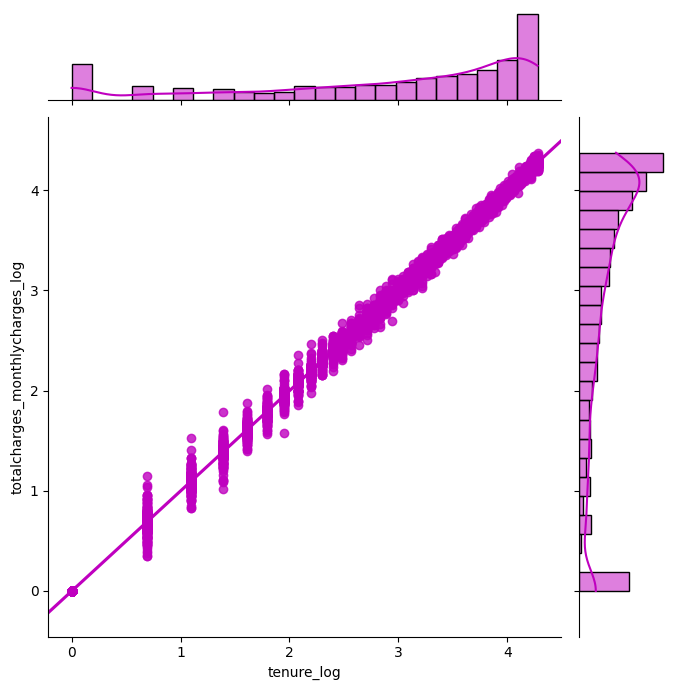

In [93]:
Y = df_ml["totalcharges_monthlycharges_log"]
X = df_ml["tenure_log"]

sns.jointplot(x=X, y=Y, data=df_ml,kind="reg", truncate=False,color="m", height=7)
X = sm.add_constant(X) # Añadimos la intercepción (beta_0)

# Ajustamos el modelo
modelo = sm.OLS(Y, X).fit()

# Mostramos el p-value y R-squared
print(modelo.summary())


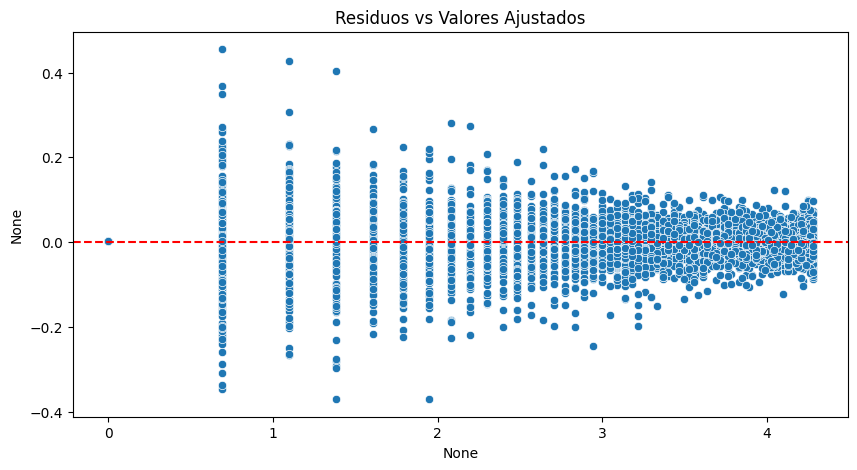

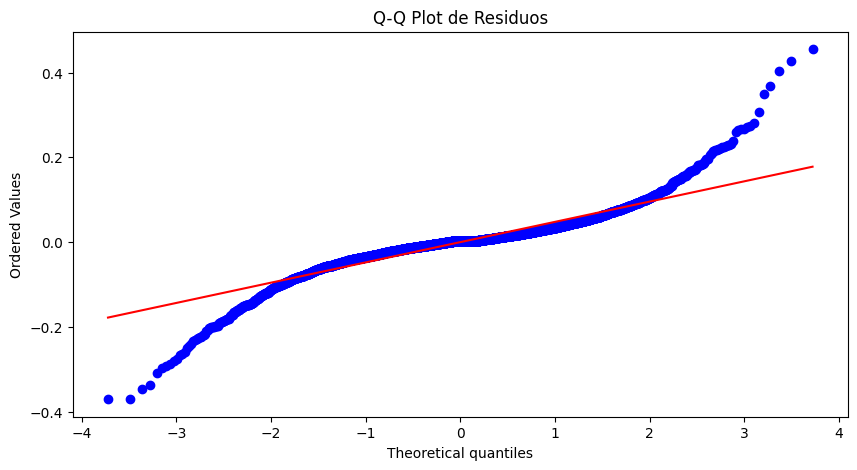

In [94]:
residuos=modelo.resid
# Gráfica de Residuos vs Ajustados (Homocedasticidad)
plt.figure(figsize=(10,5))
sns.scatterplot(x=modelo.fittedvalues, y=residuos)
plt.axhline(y=np.mean(residuos), color='r', linestyle='--')
plt.title('Residuos vs Valores Ajustados')
plt.show()

# Q-Q Plot para ver si los residuos son normales
plt.figure(figsize=(10,5))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

In [95]:
shapiro_test = stats.shapiro(residuos)

print(f"Estadístico Shapiro: {shapiro_test.statistic:.4f}")
print(f"p-value Shapiro: {shapiro_test.pvalue:.4e}")

if shapiro_test.pvalue < 0.05:
    print("Rechazamos H0: Los residuos NO siguen una distribución normal.")
else:
    print("No podemos rechazar H0: Los residuos parecen normales.")


# El test requiere los residuos y la matriz de variables independientes (X)
names = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test_bp = sms.het_breuschpagan(residuos, modelo.model.exog)

print(f"p-value de Breuch-Pagan: {test_bp[1]:4e}")

if test_bp[1] < 0.05:
    print("Rechazamos H0: Hay Heterocedasticidad (varianza no constante).")
else:
    print("No podemos rechazar H0: Hay Homocedasticidad.")    

Estadístico Shapiro: 0.8858
p-value Shapiro: 6.3095e-58
Rechazamos H0: Los residuos NO siguen una distribución normal.
p-value de Breuch-Pagan: 3.802925e-60
Rechazamos H0: Hay Heterocedasticidad (varianza no constante).


c:\Users\jherr\Proyectos\Telco_Customer_Chrun\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7032.
  res = hypotest_fun_out(*samples, **kwds)


**Interpretación Estadística:**
Un ajuste lineal cercano a la perfección ($R^2 \approx 0.99$) nos indicaría una estructura de precios muy rígida. Por el contrario, la presencia de **heterocedasticidad** (varianza no constante en los residuos) sugiere que existen cargos adicionales, descuentos o penalizaciones que no están explicados únicamente por la antigüedad, y que podrían ser predictores críticos del *Churn*.

**Diagnóstico de Residuos y Validación de Hipótesis**
Tras ajustar el modelo de regresión lineal sobre las variables transformadas, se procedió a validar los supuestos clásicos de Gauss-Markov. Los hallazgos fueron determinantes:

1. **Rechazo de Homocedasticidad:** La varianza de los residuos no es constante, exhibiendo un patrón de "embudo" o dispersión creciente. Esto indica que el error de predicción de la factura total aumenta en ciertos segmentos de clientes, sugiriendo la presencia de variables ocultas (promociones, penalizaciones o servicios variables).
2. **Rechazo de Normalidad:** Las pruebas estadísticas confirmaron que los residuos no siguen una distribución normal. La presencia de colas pesadas y sesgo sugiere que el modelo lineal no es suficiente para capturar la complejidad total del comportamiento financiero de los usuarios.

In [96]:
df_ml = df_ml.drop(columns=['tenure'])
df_ml = df_ml.drop(columns=['totalcharges_monthlycharges_log'])
df_ml["residuos"] = residuos

Tras el análisis de regresión, se han realizado tres ajustes estratégicos en el dataset para optimizar el entrenamiento del modelo de Machine Learning:

1. **`df_ml.drop(columns=['tenure'])`**: 
   Se elimina la variable de antigüedad original. Al haber incluido `tenure_log`, mantener la variable original generaría redundancia (multicolinealidad). La versión logarítmica es más eficiente para capturar el comportamiento del cliente en los meses críticos (los primeros), que es donde ocurre la mayor tasa de Churn.

2. **`df_ml.drop(columns=['totalcharges_monthlycharges_log'])`**: 
   Esta variable fue nuestra "herramienta de diagnóstico" para la regresión. Una vez extraída la información que necesitábamos, la eliminamos para evitar que el modelo se confunda con variables que tienen una correlación casi perfecta con otras, simplificando así la arquitectura del dataset.

3. **`df_ml["residuos"] = residuos`**: 
   Esta es la aportación más innovadora del proyecto. En lugar de descartar el error de la regresión, lo integramos como una nueva variable. Estos residuos representan la **desviación de facturación**:
   * **Residuos Positivos:** Clientes que pagan más de lo esperado según su antigüedad.
   * **Residuos Negativos:** Clientes que tienen descuentos o cargos menores a la media.
   
   Al entregarle estos "errores" al Ensemble, permitimos que los algoritmos identifiquen si una anomalía en el precio es un detonante para que el cliente decida abandonar la compañía.

### Ingeniería de Características

Se aplicó la transformación logarítmica a la variable de antigüedad (`tenure`). 
* **Justificación:** El riesgo de fuga no es lineal respecto al tiempo. Los primeros meses son críticos; un cliente que sobrevive al primer año tiene una probabilidad de fuga mucho menor que un recién llegado. El logaritmo "amplía" la visión de esos primeros meses, permitiendo al modelo aprender mejor el comportamiento en el periodo de mayor riesgo.

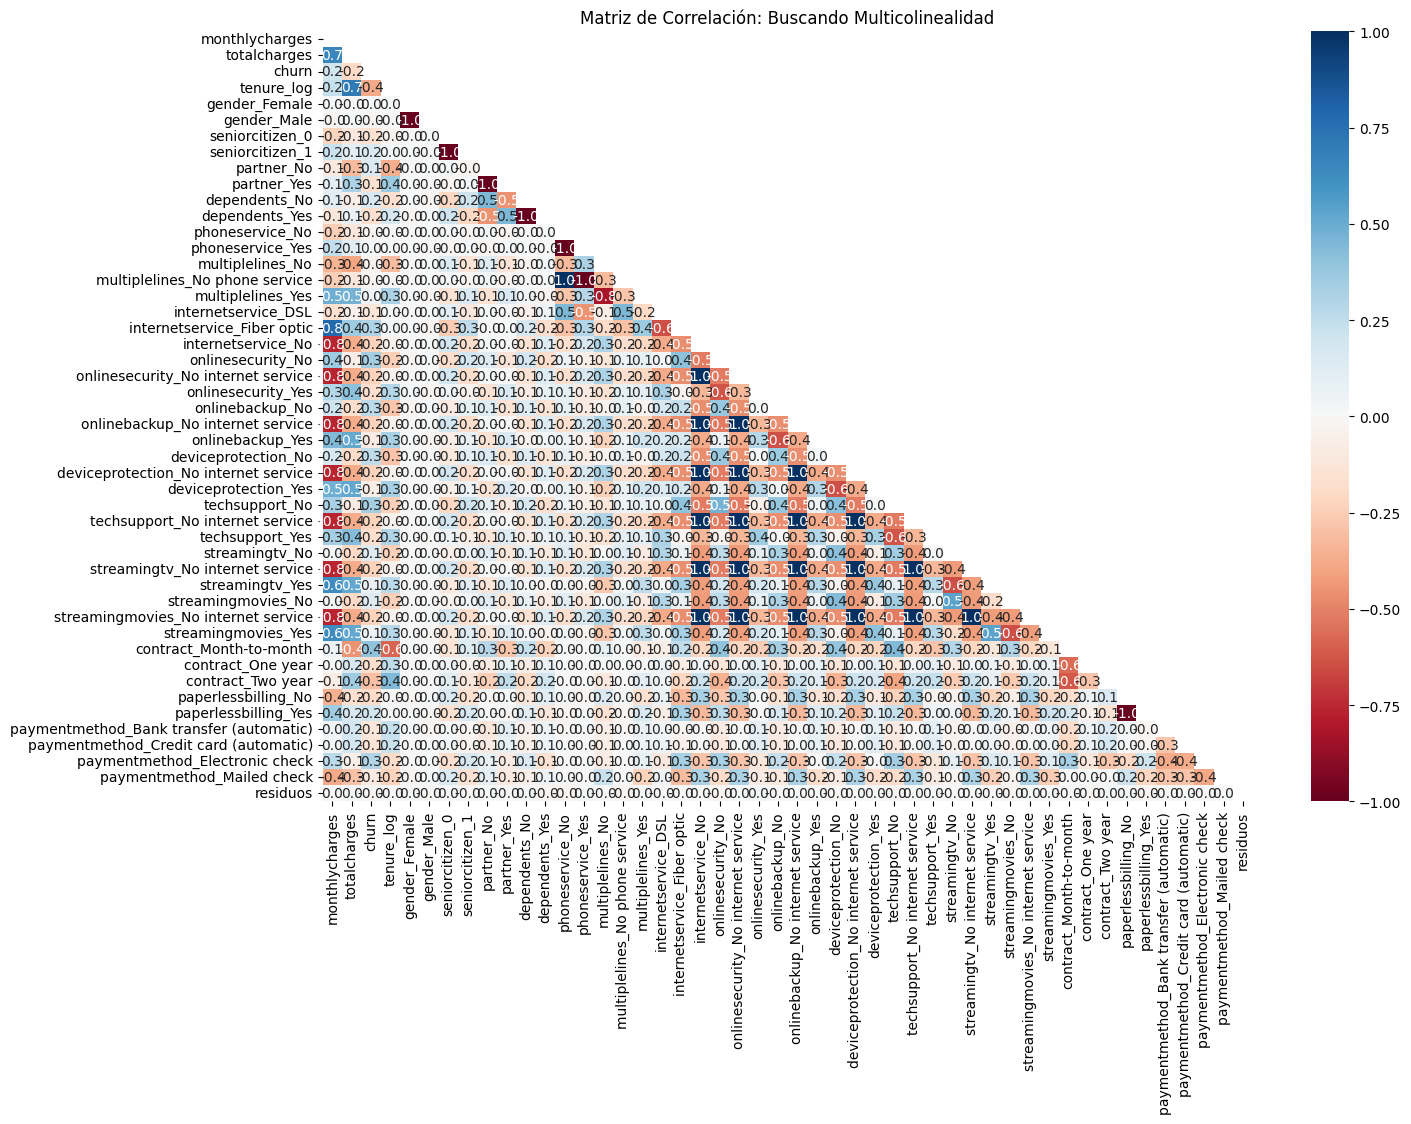

In [97]:
plt.figure(figsize=(15,10))
matriz_corr=df_ml.corr()

mask=np.triu(np.ones_like(matriz_corr,dtype=bool))

sns.heatmap(matriz_corr,mask=mask,annot=True, fmt=".1f", cmap="RdBu")
plt.title('Matriz de Correlación: Buscando Multicolinealidad')
plt.show()

Tras un análisis de correlación y de la estructura de las variables tras el One-Hot Encoding, se procedió a la eliminación de variables redundantes bajo tres criterios técnicos:

**Mitigación de Multicolinealidad**
* **`totalcharges`**: Se elimina al presentar una correlación extremadamente alta con la combinación de `tenure` y `monthlycharges`. Su información ya está contenida, de forma más limpia, en la variable de **residuos** y las versiones logarítmicas.
* **Variables Binarias Redundantes**: Se eliminaron columnas como `gender_Male`, `phoneservice_Yes` y `multiplelines_Yes`. Al ser variables dicotómicas, la información de una categoría está implícitamente contenida en la otra (si no es 'Male', es 'Female'), evitando así la redundancia de datos.

**Eliminación de Categorías (No internet service)**
Se identificó que el One-Hot Encoding generó múltiples columnas con el valor `'No internet service'`:
* **Acción:** `df_ml.drop(columns=cols_redundantes)`
* **Justificación:** Estas columnas son réplicas exactas entre sí. Si un cliente no tiene servicio de internet, esta información ya queda registrada en la variable principal de `InternetService_No`. Mantener múltiples columnas que dicen lo mismo penaliza la eficiencia del modelo sin añadir valor predictivo.

**Consistencia Lógica**
* **`multiplelines_No phone service`**: Se elimina por ser redundante con la variable de servicio telefónico base. Un modelo más esbelto (lean) converge más rápido y es menos propenso al sobreajuste (*overfitting*).

In [98]:
cols_redundantes = [col for col in df_ml.columns if col.endswith('No internet service')]

df_ml = df_ml.drop(columns=cols_redundantes)
df_ml = df_ml.drop(columns=['multiplelines_No phone service'])

df_ml = df_ml.drop(columns=["totalcharges", "gender_Male","multiplelines_Yes","phoneservice_Yes"])

la matriz de correlación queda de la siguiente manera:

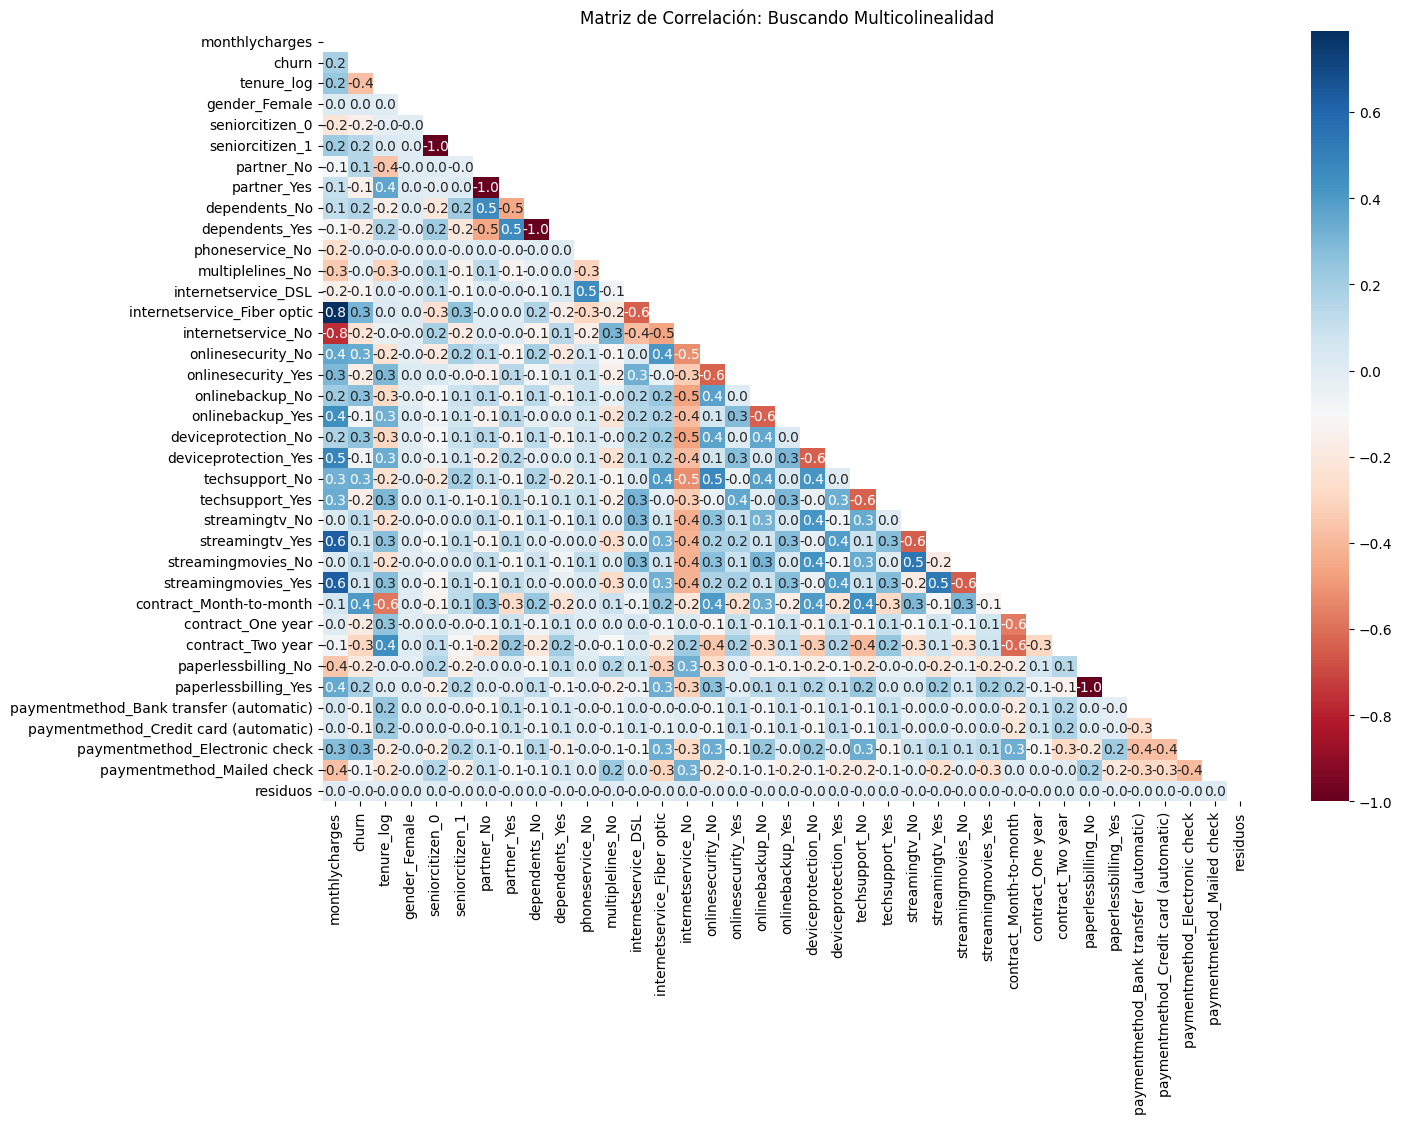

In [99]:
plt.figure(figsize=(15,10))
matriz_corr=df_ml.corr()

mask=np.triu(np.ones_like(matriz_corr,dtype=bool))

sns.heatmap(matriz_corr,mask=mask,annot=True, fmt=".1f", cmap="RdBu")
plt.title('Matriz de Correlación: Buscando Multicolinealidad')
plt.show()

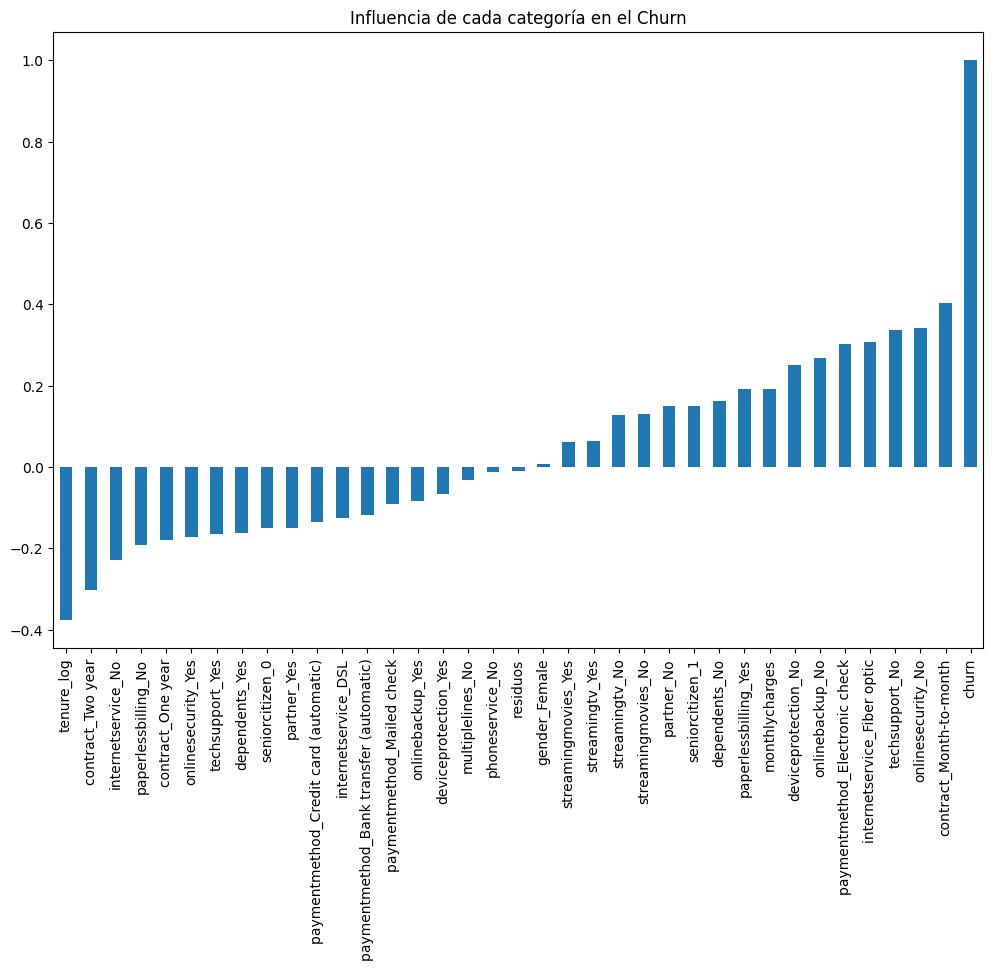

In [100]:
plt.figure(figsize=(12, 8))
# Correlación de todas las variables con la columna 'churn'
df_ml.corr()['churn'].sort_values(ascending=True).plot(kind='bar')
plt.title('Influencia de cada categoría en el Churn')
plt.show()

## 4. Visualización de AED

In [101]:

# num_vars = ['tenure_log', 'monthlycharges', 'residuos_facturacion', 'churn',"totalcharges_monthlycharges_log"]
# # Creamos el gráfico mejorado
# g=sns.pairplot(
#     df_ml[num_vars], 
#     hue="churn", 
#     corner=True,
#     kind="scatter",
#     diag_kind="kde", 
#     plot_kws={'alpha': 0.4, 's': 20} 
# )
# g.map_lower(sns.kdeplot, levels=5, color=".2")


In [102]:
# No depende del género
# sns.catplot(
#     data=df, x="churn", y="monthlycharges", hue="gender",
#     kind="violin", split=True,
# )

# sns.catplot(
#     data=df, x="churn", y="totalcharges", hue="gender",
#     kind="violin", split=True,
# )

<Axes: xlabel='tenure', ylabel='count'>

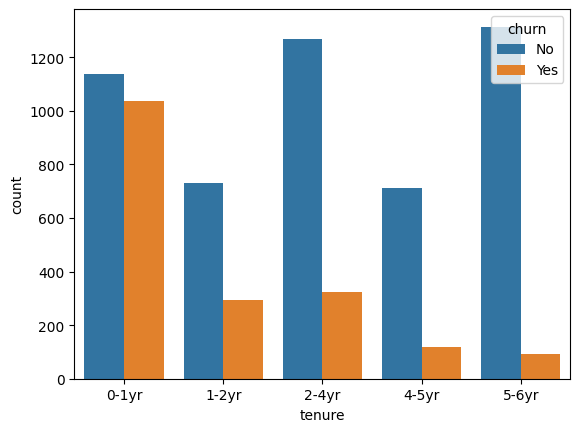

In [103]:
sns.countplot(x=pd.cut(df["tenure"],bins=[0,12,24,48,60,72],labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']), hue='churn', data=df)

Existe un desbalance de clases de Churn, 26% de Yes y 74% es No. Es por ello que habrá que usar métricas como F1-Score y curva Precisión Recall en vez de la curva ROC y accuracy

# 5. Modelo


In [104]:
def train_and_evaluate_ensemble(X, y, numeric_features):
    """
    Función que realiza el split, escalado, SMOTE, evaluación de modelos base
    y entrenamiento del Ensemble final con optimización de umbral.
    """
    # 1. Train-Test Split con estratificación
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=40, shuffle=True, stratify=y
    )

    # 2. Escalado de variables numéricas
    scaler = StandardScaler()
    X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test[numeric_features] = scaler.transform(X_test[numeric_features])

    # 3. Balanceo de clases con SMOTE
    smote = SMOTE(sampling_strategy=1, random_state=40)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    print(f"INFO: Distribución tras SMOTE: {Counter(y_train_res)}\n")

    # 4. Evaluación de modelos base para comparar
    base_models = {
        'XGB': XGBClassifier(random_state=42),
        'RF': RandomForestClassifier(random_state=42),
        'LGBM': LGBMClassifier(random_state=42, verbose=-1),
        'LogReg': LogisticRegression(max_iter=1000)
    }

    print("--- Evaluación de Modelos Base (Optimización de Umbral) ---")
    for name, model in base_models.items():
        tuned = TunedThresholdClassifierCV(estimator=model, scoring="f1", cv=5).fit(X_train_res, y_train_res)
        y_pred = (tuned.predict_proba(X_test)[:, 1] > tuned.best_threshold_).astype(int)
        print(f"Modelo: {name} | Umbral Óptimo: {tuned.best_threshold_:.3f}")
        # Aquí podrías imprimir solo el F1 si no quieres que el log sea eterno

    # 5. Configuración y entrenamiento del Ensemble
    # Nota: No usamos scale_pos_weight aquí porque ya aplicamos SMOTE
    voting_clf = VotingClassifier(
        estimators=[
            ('xgb', XGBClassifier(random_state=42)),
            ('rf', RandomForestClassifier(random_state=42)),
            ('lgbm', LGBMClassifier(random_state=42, verbose=-1))
        ],
        voting='soft'
    )

    print("\n--- Entrenando Ensemble Final ---")
    ensemble_tuned = TunedThresholdClassifierCV(estimator=voting_clf, scoring="f1", cv=5)
    ensemble_tuned.fit(X_train_res, y_train_res)

    # 6. Predicciones Finales
    y_probs = ensemble_tuned.predict_proba(X_test)[:, 1]
    umbral = ensemble_tuned.best_threshold_
    y_pred = (y_probs > umbral).astype(int)

    return ensemble_tuned, X_test, y_test, y_pred, y_probs


num_cols = ['monthlycharges', 'tenure_log', 'residuos']
#num_cols = ['monthlycharges', 'tenure_log']
X = df_ml.drop(columns='churn')
y = df_ml['churn']

final_model, X_test_final, y_test_final, y_pred_final, y_probs_final = train_and_evaluate_ensemble(X, y, num_cols)

# Imprimir reporte final
print("\nREPORTE FINAL ENSEMBLE:")
print(classification_report(y_test_final, y_pred_final))

INFO: Distribución tras SMOTE: Counter({0: 4130, 1: 4130})

--- Evaluación de Modelos Base (Optimización de Umbral) ---
Modelo: XGB | Umbral Óptimo: 0.364
Modelo: RF | Umbral Óptimo: 0.515
Modelo: LGBM | Umbral Óptimo: 0.455
Modelo: LogReg | Umbral Óptimo: 0.415

--- Entrenando Ensemble Final ---

REPORTE FINAL ENSEMBLE:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



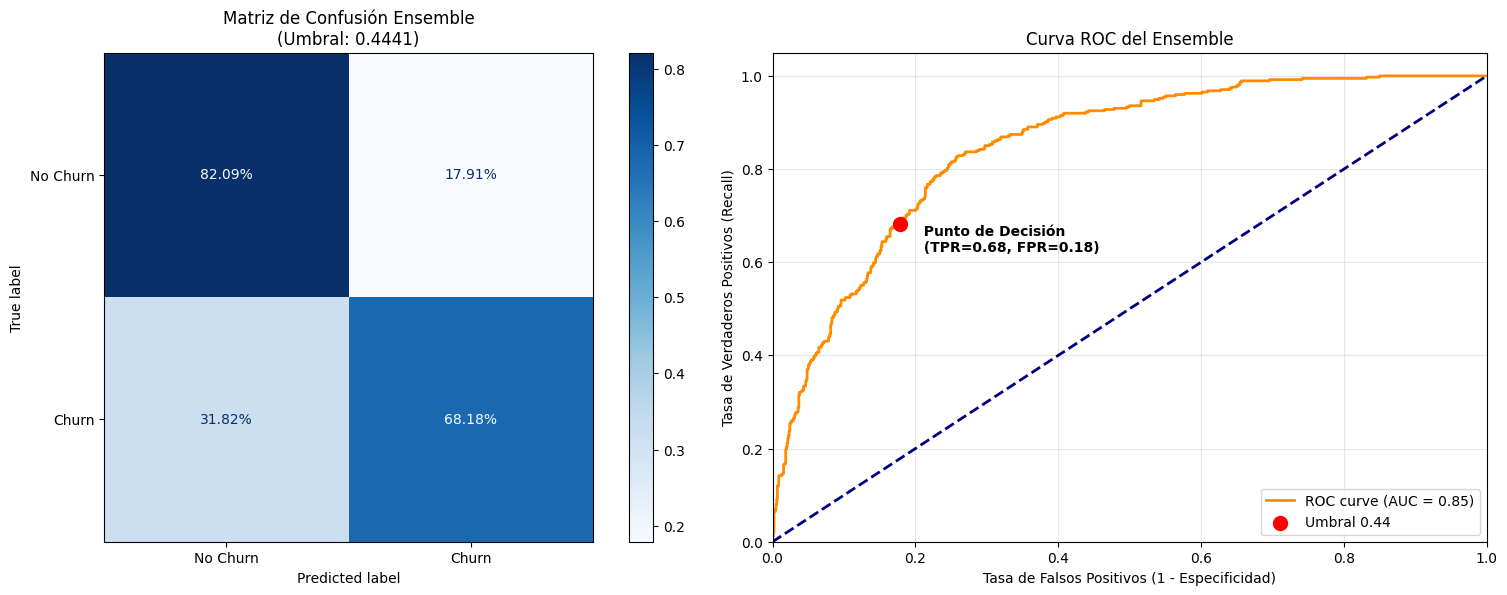

In [105]:
# --- AJUSTE DE VISUALIZACIÓN PARA LA FUNCIÓN ---

# Extraemos el umbral óptimo del modelo final devuelto por la función
umbral_final = final_model.best_threshold_

# Crear la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFICA 1: Matriz de Confusión Normalizada ---
# Usamos los resultados que salieron de la función
cm = confusion_matrix(y_test_final, y_pred_final, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax1, cmap='Blues', values_format='.2%')
ax1.set_title(f'Matriz de Confusión Ensemble\n(Umbral: {umbral_final:.4f})')

# --- GRAFICA 2: Curva ROC con Punto de Decisión ---
# Usamos las probabilidades finales y el test final
fpr, tpr, thresholds = roc_curve(y_test_final, y_probs_final)
roc_auc = auc(fpr, tpr)

# Encontrar el índice del umbral óptimo en la curva ROC
idx = np.argmin(np.abs(thresholds - umbral_final))

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Umbral {umbral_final:.2f}', zorder=5)
ax2.annotate(f'  Punto de Decisión\n  (TPR={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})', 
             (fpr[idx], tpr[idx]), xytext=(10, -20), textcoords='offset points',
             fontsize=10, fontweight='bold', color='black')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax2.set_title('Curva ROC del Ensemble')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Validación del modelo

------

Curva ROC, AUC. Es mejor tener falsos positivos que falsos negativos (mejor que se intente convencer de que se quede alguien que se iba a quedar)

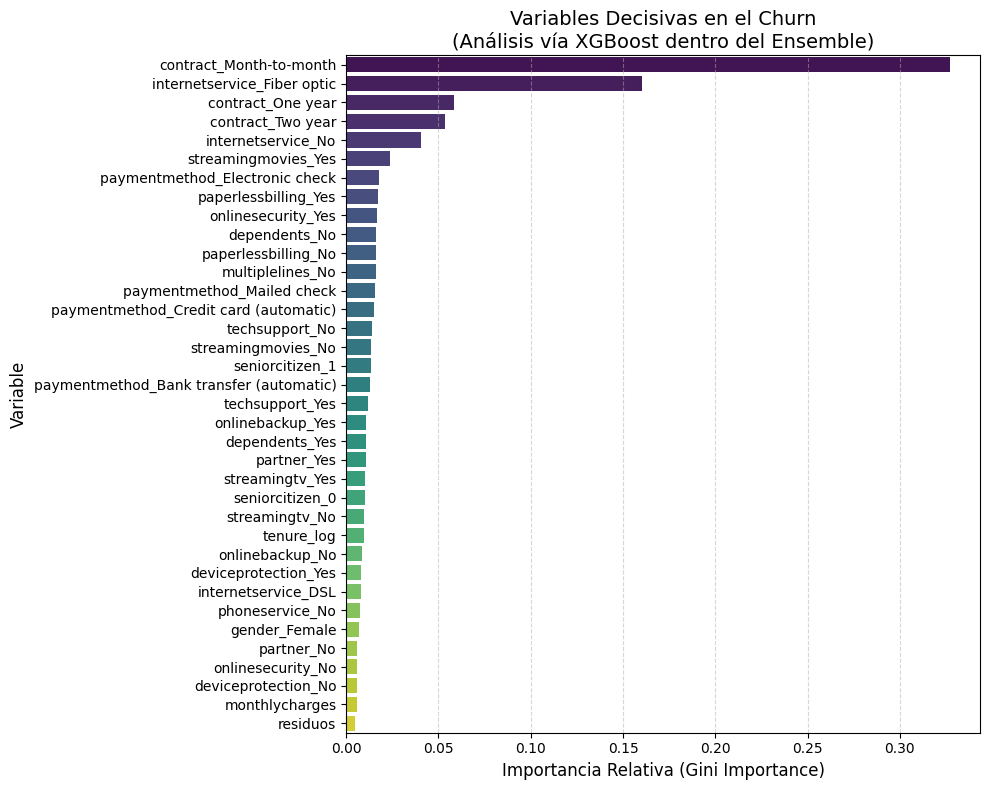

In [106]:
# 1. Extraer el XGBoost desde el interior del TunedThreshold y del VotingClassifier
# final_model -> .estimator_ (VotingClassifier) -> .named_estimators_['xgb']
xgb_internal = final_model.estimator_.named_estimators_['xgb']

# 2. Obtener las importancias y los nombres de las columnas
importancias = xgb_internal.feature_importances_
nombres_columnas = X.columns # Usamos X porque es el DataFrame original antes del split

# 3. Crear DataFrame, ordenar y filtrar (Top 15 para mayor claridad)
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 4. Gráfico
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia, 
    hue='Variable', # Para evitar advertencias de versiones recientes de Seaborn
    palette='viridis', 
    legend=False
)

plt.title('Variables Decisivas en el Churn\n(Análisis vía XGBoost dentro del Ensemble)', fontsize=14)
plt.xlabel('Importancia Relativa (Gini Importance)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<table data-path-to-node="10"><thead><tr><td><span data-path-to-node="10,0,0,0">Escenario</span></td><td><span data-path-to-node="10,0,1,0">Umbral</span></td><td><span data-path-to-node="10,0,2,0">Recall (Detección)</span></td><td><span data-path-to-node="10,0,3,0">Precisión (Eficiencia)</span></td><td><span data-path-to-node="10,0,4,0">Perfil de Campaña</span></td></tr></thead><tbody><tr><td><span data-path-to-node="10,1,0,0"><b data-path-to-node="10,1,0,0" data-index-in-node="0">Equilibrado (F1)</b></span></td><td><span data-path-to-node="10,1,1,0">0.52</span></td><td><span data-path-to-node="10,1,2,0">0.75</span></td><td><span data-path-to-node="10,1,3,0">0.51</span></td><td><span data-path-to-node="10,1,4,0">Campañas estándar.</span></td></tr><tr><td><span data-path-to-node="10,2,0,0"><b data-path-to-node="10,2,0,0" data-index-in-node="0">Manual / Tu intuición</b></span></td><td><span data-path-to-node="10,2,1,0">0.40</span></td><td><span data-path-to-node="10,2,2,0">0.84</span></td><td><span data-path-to-node="10,2,3,0">0.49</span></td><td><span data-path-to-node="10,2,4,0">Punto dulce (sweet spot).</span></td></tr><tr><td><span data-path-to-node="10,3,0,0"><b data-path-to-node="10,3,0,0" data-index-in-node="0">Agresivo (F2)</b></span></td><td><span data-path-to-node="10,3,1,0">0.15</span></td><td><span data-path-to-node="10,3,2,0"><b data-path-to-node="10,3,2,0" data-index-in-node="0">0.93</b></span></td><td><span data-path-to-node="10,3,3,0">0.42</span></td><td><span data-path-to-node="10,3,4,0">Prevención crítica de fugas.</span></td></tr></tbody></table>

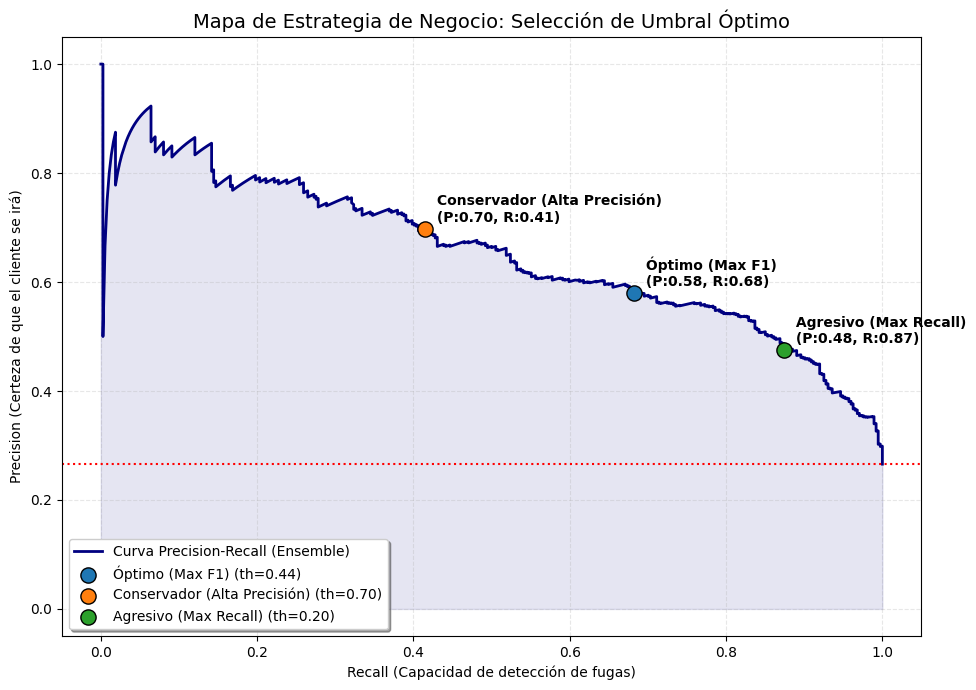

In [107]:
# 1. Obtener probabilidades y curva P-R del modelo final (Ensemble)
precision, recall, thresholds = precision_recall_curve(y_test_final, y_probs_final)

# 2. Definir los puntos estratégicos basados en los nuevos resultados
# El umbral equilibrado es el que optimizó tu función para el F1-Score
umbral_f1 = final_model.best_threshold_

puntos_interes = {
    'Óptimo (Max F1)': umbral_f1,
    'Conservador (Alta Precisión)': 0.70, # Ejemplo: Solo atacar casos muy seguros
    'Agresivo (Max Recall)': 0.20        # Ejemplo: Capturar casi todo el churn
}

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='navy', lw=2, label='Curva Precision-Recall (Ensemble)')

# 3. Marcar los umbrales en la curva
for nombre, th in puntos_interes.items():
    # El array 'thresholds' tiene un elemento menos que precision/recall
    idx = np.argmin(np.abs(thresholds - th))
    plt.scatter(recall[idx], precision[idx], s=120, edgecolors='black', label=f'{nombre} (th={th:.2f})', zorder=5)
    plt.annotate(f" {nombre}\n (P:{precision[idx]:.2f}, R:{recall[idx]:.2f})", 
                 (recall[idx], precision[idx]), 
                 fontsize=10, fontweight='bold', xytext=(5, 5), textcoords='offset points')

plt.xlabel('Recall (Capacidad de detección de fugas)')
plt.ylabel('Precision (Certeza de que el cliente se irá)')
plt.title('Mapa de Estrategia de Negocio: Selección de Umbral Óptimo', fontsize=14)
plt.legend(loc="lower left", frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')
plt.fill_between(recall, precision, alpha=0.1, color='navy')

# Añadir línea de referencia (baseline)
plt.axhline(y=y_test_final.mean(), color='red', linestyle=':', label='Baseline (Azar)')

plt.tight_layout()
plt.show()